In [1]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00


In [8]:
import pandas as pd

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

import seaborn as sns

In [9]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
df = df[["title","description"]]

df.head()

,title,description
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm..."
1,Blood & Water,"After crossing paths at a party, a Cape Town t..."
2,Ganglands,To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,In a city of coaching centers known to train I...


In [11]:
analyzer = SentimentIntensityAnalyzer()

In [12]:
def get_sentiment(text):

    score = analyzer.polarity_scores(str(text))

    compound = score["compound"]

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [15]:
df["Sentiment"] = df["description"].apply(get_sentiment)
df.head(10)
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,4071
Negative,3757
Neutral,979


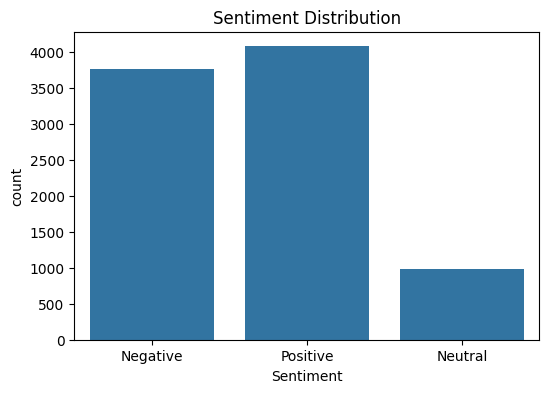

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Sentiment")

plt.title("Sentiment Distribution")

plt.show()

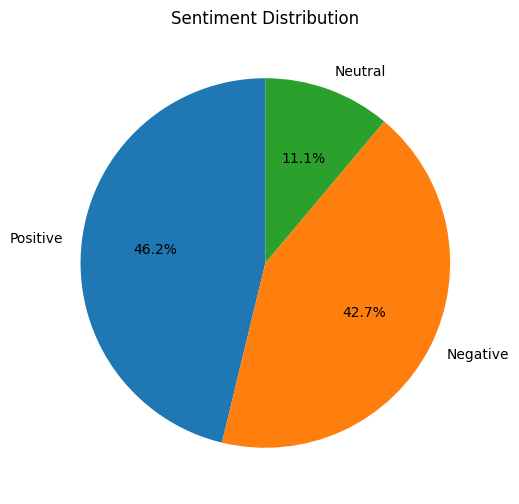

In [17]:
counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Distribution")

plt.show()

In [18]:
df[df["Sentiment"]=="Positive"].head(10)

,title,description,Sentiment
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",Positive
4,Kota Factory,In a city of coaching centers known to train I...,Positive
5,Midnight Mass,The arrival of a charismatic young priest brin...,Positive
6,My Little Pony: A New Generation,Equestria's divided. But a bright-eyed hero be...,Positive
8,The Great British Baking Show,A talented batch of amateur bakers face off in...,Positive
13,Confessions of an Invisible Girl,When the clever but socially-awkward Tetê join...,Positive
19,Jaguar,"In the 1960s, a Holocaust survivor joins a gro...",Positive
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,From arcade games to sled days and hiccup cure...,Positive
24,Jeans,When the father of the man she loves insists t...,Positive
25,Love on the Spectrum,Finding love can be hard for anyone. For young...,Positive


In [19]:
df[df["Sentiment"]=="Negative"].head(10)

,title,description,Sentiment
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",Negative
1,Blood & Water,"After crossing paths at a party, a Cape Town t...",Negative
2,Ganglands,To protect his family from a powerful drug lor...,Negative
7,Sankofa,"On a photo shoot in Ghana, an American model s...",Negative
9,The Starling,A woman adjusting to life after a loss contend...,Negative
10,"Vendetta: Truth, Lies and The Mafia","Sicily boasts a bold ""Anti-Mafia"" coalition. B...",Negative
11,Bangkok Breaking,"Struggling to earn a living in Bangkok, a man ...",Negative
12,Je Suis Karl,After most of her family is murdered in a terr...,Negative
14,Crime Stories: India Detectives,Cameras following Bengaluru police on the job ...,Negative
17,Falsa identidad,Strangers Diego and Isabel flee their home in ...,Negative


In [20]:
df.to_csv("Netflix_Sentiment_Analysis.csv",index=False)

In [21]:
from google.colab import files

files.download("Netflix_Sentiment_Analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>